# **Импорты и подготовка данных**

In [ ]:
import numpy as np
import pandas as pd
import os
import zipfile
import gdown
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras import utils

# Скачивание базы
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/writers.zip', None, quiet=True)

# Распаковка архива
with zipfile.ZipFile('writers.zip', 'r') as zip_ref:
    zip_ref.extractall('writers')

# Список авторов (имена папок в архиве)
authors = os.listdir('writers')
num_classes = len(authors)

print(f"Найдено авторов: {num_classes}")
print(f"Имена авторов: {authors}")

Найдено авторов: 12
Имена авторов: ['(О. Генри) Тестовая_20 вместе.txt', '(Рэй Брэдберри) Обучающая_22 вместе.txt', '(Булгаков) Обучающая_5 вместе.txt', '(Клиффорд_Саймак) Тестовая_2 вместе.txt', '(Булгаков) Тестовая_2 вместе.txt', '(Макс Фрай) Тестовая_2 вместе.txt', '(Стругацкие) Обучающая_5 вместе.txt', '(О. Генри) Обучающая_50 вместе.txt', '(Рэй Брэдберри) Тестовая_8 вместе.txt', '(Стругацкие) Тестовая_2 вместе.txt', '(Клиффорд_Саймак) Обучающая_5 вместе.txt', '(Макс Фрай) Обучающая_5 вместе.txt']


# **Загрузка и очистка текстов**

In [ ]:
train_text = []
test_text = []

for i, author in enumerate(authors):
    path = f'writers/'
    all_files = os.listdir(path)

    # Собираем весь текст автора
    full_text = ""
    for file in all_files:
        with open(path + file, 'r', encoding='utf-8') as f:
            text = f.read().replace('\n', ' ') # Убираем переносы строк
            full_text += ' ' + text

    # Делим на обучающую (80%) и проверочную (20%) выборки
    split_index = int(len(full_text) * 0.8)
    train_text.append(full_text[:split_index])
    test_text.append(full_text[split_index:])

print("Тексты успешно загружены и разделены.")

Тексты успешно загружены и разделены.


# **Нарезка текста на «окна»**

In [ ]:
def get_sequences(tokens, window, step):
    sequences = []
    for i in range(0, len(tokens) - window + 1, step):
        sequences.append(tokens[i : i + window])
    return sequences

def create_dataset(texts, tokenizer, window, step):
    x_data = []
    y_data = []

    # Превращаем тексты в последовательности индексов слов
    all_tokens = tokenizer.texts_to_sequences(texts)

    for i, tokens in enumerate(all_tokens):
        # Нарезаем токены на окна
        samples = get_sequences(tokens, window, step)
        x_data.extend(samples)
        # Для каждого окна запоминаем индекс автора (метку класса)
        y_data.extend([i] * len(samples))

    return np.array(x_data), np.array(y_data)

# **Обучение 9 моделей с разными гиперпараметрами**

In [ ]:
import gc # Библиотека для сборки мусора
from tensorflow.keras import backend as K # Для очистки сессии Keras

# Облегченные конфиги для стабильности
configs = [
    (10000, 1000, 500), (10000, 1200, 500), (10000, 1500, 600),
    (10000, 1000, 700), (12000, 1000, 800), (10000, 2000, 900),
    (10000, 1100, 500), (10000, 1300, 600), (10000, 1400, 700)
]

for i, (v_size, w_width, step) in enumerate(configs):
    K.clear_session()
    gc.collect()

    print(f"\n--- Эксперимент {i+1} ---")

    tokenizer = Tokenizer(num_words=v_size, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n', lower=True)
    tokenizer.fit_on_texts(train_text)

    x_train_seq, y_train = create_dataset(train_text, tokenizer, w_width, step)
    x_test_seq, y_test = create_dataset(test_text, tokenizer, w_width, step)

    # КЛЮЧЕВОЕ ИЗМЕНЕНИЕ: используем dtype='uint8' для экономии RAM
    x_train = tokenizer.sequences_to_matrix(x_train_seq.tolist(), mode='binary').astype('uint8')
    x_test = tokenizer.sequences_to_matrix(x_test_seq.tolist(), mode='binary').astype('uint8')

    y_train_cat = utils.to_categorical(y_train, num_classes)
    y_test_cat = utils.to_categorical(y_test, num_classes)

    model = Sequential([
        Dense(128, activation='relu', input_shape=(v_size,)), # Уменьшили кол-во нейронов для скорости
        BatchNormalization(),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Уменьшим количество эпох до 5, чтобы просто проверить работоспособность
    history=model.fit(x_train, y_train_cat, epochs=5, batch_size=128,
              validation_data=(x_test, y_test_cat), verbose=1)

    # После обучения сразу удаляем всё тяжелое
    del x_train, x_test, x_train_seq, x_test_seq


--- Эксперимент 1 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.0469 - loss: 2.8281 - val_accuracy: 0.0833 - val_loss: 2.4993
Epoch 2/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0668 - loss: 2.5294 - val_accuracy: 0.0833 - val_loss: 2.4876
Epoch 3/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0731 - loss: 2.5030 - val_accuracy: 0.0833 - val_loss: 2.4865
Epoch 4/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0748 - loss: 2.4951 - val_accuracy: 0.0833 - val_loss: 2.4865
Epoch 5/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0756 - loss: 2.4923 - val_accuracy: 0.0833 - val_loss: 2.4864

--- Эксперимент 2 ---
Epoch 1/5
299/299 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.0451 - loss: 2.8568 - val_accuracy: 0.0833 - val_loss: 2.5082
Epoch 2/5
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0648 - loss: 2.5360 - val_accuracy: 0.0833 - val_loss: 2.4894
Epoch 3/5
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0680 - loss: 2.5059 -

# **Построение графиков**

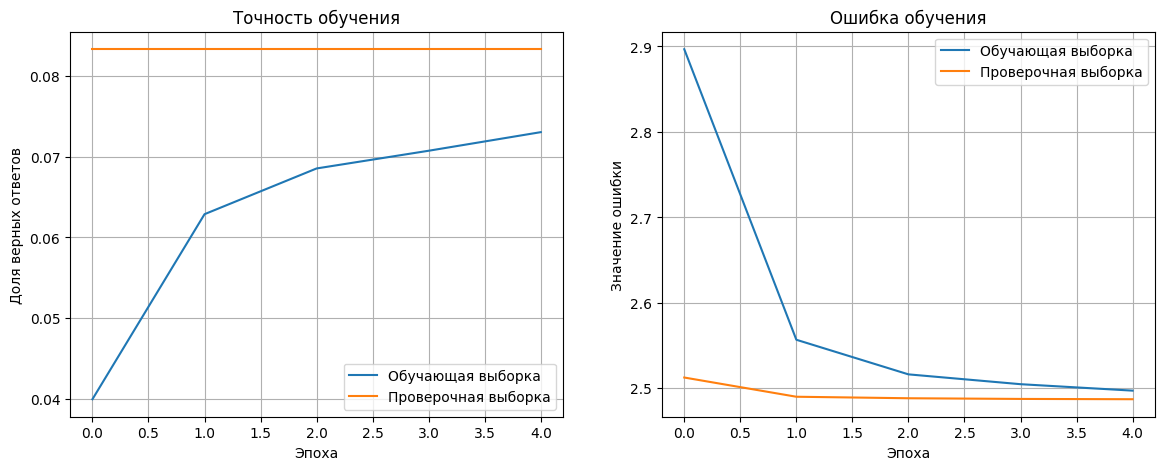

In [ ]:
import matplotlib.pyplot as plt

# Функция для вывода графиков
def plot_history(history):
    plt.figure(figsize=(14, 5))

    # График точности (Accuracy)
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Обучающая выборка')
    plt.plot(history.history['val_accuracy'], label='Проверочная выборка')
    plt.title('Точность обучения')
    plt.xlabel('Эпоха')
    plt.ylabel('Доля верных ответов')
    plt.legend()
    plt.grid(True)

    # График ошибки (Loss)
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Обучающая выборка')
    plt.plot(history.history['val_loss'], label='Проверочная выборка')
    plt.title('Ошибка обучения')
    plt.xlabel('Эпоха')
    plt.ylabel('Значение ошибки')
    plt.legend()
    plt.grid(True)

    plt.show()

# Вызываем функцию после обучения модели
plot_history(history)